In [3]:
import matplotlib.pyplot as plt
import os
import cv2
import pandas as pd

In [4]:
source = r"C:\Users\1tram\OneDrive\Documents\DoAnTotNghiep\All_Dataset\DoDongThuan"

In [5]:
def load_url(source_dir, tag, anno = 0):
    result = []
    folder_dir = ""
    
    if tag == "img":
        folder_dir = os.path.join(source_dir, "img")
    if tag == "label":
        if anno == 1:
            folder_dir = os.path.join(source_dir, "Nam_labels")
        elif anno == 2:
            folder_dir = os.path.join(source_dir, "Trung_labels")
    
    for filename in os.listdir(folder_dir):
        result.append(os.path.join(folder_dir, filename))
    
    return result

In [6]:
def make_df(boxes):
    df = pd.DataFrame(boxes, columns=['class_id', 'x_min', 'y_min', 'x_max', 'y_max'])
    return df

In [7]:
## danh sách các đường dẫn đến từng file
img_dir = load_url(source, tag="img")
nam_label_dir = load_url(source, tag="label", anno=1)
trung_label_dir = load_url(source, tag="label", anno=2)

In [8]:
## chuyển từ yolo sang PascalVOC (tọa độ tuyệt đối theo kích thuốc ảnh)
def yolo_2_pascalVOC(box, img_w, img_h):
    class_id, x_center, y_center, width, height = box
    
    x_min = int((x_center - width / 2) * img_w)
    x_max = int((x_center + width / 2) * img_w)
    
    y_min = int((y_center - height / 2) * img_h)
    y_max = int((y_center + height / 2) * img_h)
    
    return int(class_id), x_min, y_min, x_max, y_max

## load tất cả các bbox có trong 1 file yolo label
def load_boxes(yolo_file, img_w, img_h):
    boxes = []
    with open(yolo_file, 'r') as f:
        for line in f.readlines():
            box = list(map(float, line.strip().split()))
            boxes.append(yolo_2_pascalVOC(box, img_w, img_h))
    return boxes

## vẽ bouding box lên ảnh
def draw_bbox(img, boxes, colors):
    img_copy = img.copy()
    
    for i, (cls_id, x_min, y_min, x_max, y_max) in enumerate(boxes):
        color = colors.get(cls_id, (255,255,255))
        cv2.rectangle(img_copy, (x_min, y_min), (x_max, y_max), color, 2)
        cv2.putText(img_copy, f"class {cls_id}_{i}", (x_min, y_min - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1, cv2.LINE_AA)
        
    return img_copy

CLASS_COLORS = {
    0: (255, 0, 0),    # Đỏ
    1: (0, 255, 0),    # Xanh lá
    2: (0, 0, 255),    # Xanh dương 
    3: (255, 165, 0)   # Cam
}

def finish_img(img_path, anno_1, anno_2, colors):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    img_h, img_w = img.shape[:2]

    boxes_1 = load_boxes(anno_1, img_w, img_h)
    boxes_2 = load_boxes(anno_2, img_w, img_h)
    
    img_1 = draw_bbox(img, boxes_1, colors)
    img_2 = draw_bbox(img, boxes_2, colors)
    
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.title("Nam_annotator")
    plt.imshow(img_1)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.title("Trung_annotator")
    plt.imshow(img_2)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return make_df(boxes_1), make_df(boxes_2)
    

In [22]:
def compute_IoU(box1, box2):
    # Tọa độ phần giao nhau
    xA = max(box1['x_min'], box2['x_min'])
    yA = max(box1['y_min'], box2['y_min'])
    xB = min(box1['x_max'], box2['x_max'])
    yB = min(box1['y_max'], box2['y_max'])
    
    # Diện tích phần giao
    inter_w = max(0, xB - xA)
    inter_h = max(0, yB - yA)
    inter_S = inter_w * inter_h
    
    # Diện tích từng box
    S_1 = (box1['x_max'] - box1['x_min']) * (box1['y_max'] - box1['y_min'])
    S_2 = (box2['x_max'] - box2['x_min']) * (box2['y_max'] - box2['y_min'])
    union_S = S_1 + S_2 - inter_S

    if union_S == 0:
        return 0.0
    
    iou = inter_S / union_S
    return iou

def match_boxes(boxes_1, boxes_2, iou_thresh = 0.5):
    class_ids = sorted(set(boxes_1['class_id']) | set(boxes_2['class_id']))
    result = []
    
    for clsid in class_ids:
        print(f"*** Matching Class {clsid}")
        print("        box_1   box_2     IoU")
        b1 = boxes_1[boxes_1['class_id'] == clsid]
        b2 = boxes_2[boxes_2['class_id'] == clsid]  
        used2 = set()
        
        for id1, box1 in b1.iterrows():
            best_iou = 0
            best_id2 = -1
            
            for id2, box2 in b2.iterrows():
                if id2 in used2:
                    continue
                iou = compute_IoU(box1, box2)
                if iou > best_iou:
                    best_iou = iou
                    best_id2 = id2
            
            if best_iou >= iou_thresh:
                print(f"   -->  *{id1}*     *{best_id2}*     {round(best_iou, 4)}")
                used2.add(best_id2)
                result.append(best_iou)
        print()
        
    avg_iou = sum(result) / len (result) if result else 0.0
    print(f"Trung bình IoU của ảnh: {avg_iou}")
    return avg_iou
        

======================= Duong_1_cam_1_27.png =======================


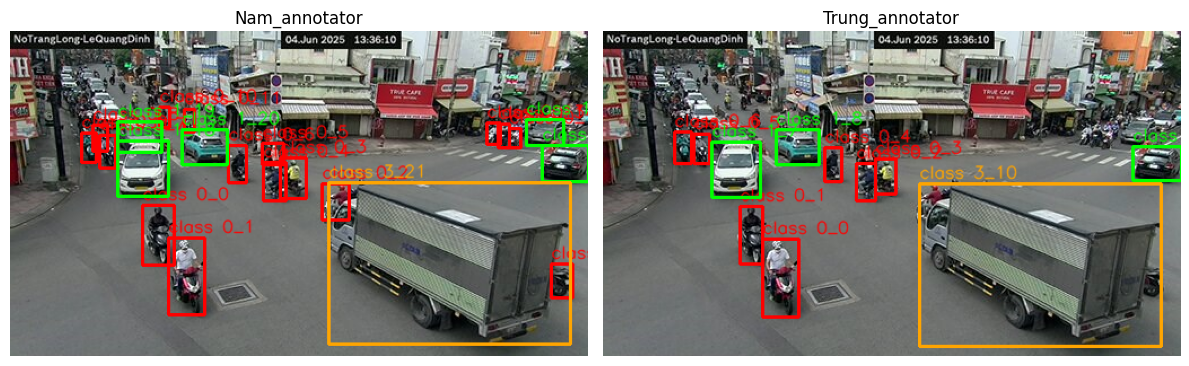

*** Matching Class 0
        box_1   box_2     IoU
   -->  *0*     *1*     0.6873
   -->  *1*     *0*     0.9003
   -->  *3*     *3*     0.6739
   -->  *4*     *2*     0.825
   -->  *6*     *4*     0.6633
   -->  *7*     *5*     0.7303
   -->  *9*     *6*     0.8048

*** Matching Class 1
        box_1   box_2     IoU
   -->  *17*     *9*     0.8965
   -->  *18*     *7*     0.9181
   -->  *20*     *8*     0.95

*** Matching Class 3
        box_1   box_2     IoU
   -->  *21*     *10*     0.9614

Trung bình IoU của ảnh: 0.8191747594699702

======================= Duong_1_cam_2_18.png =======================


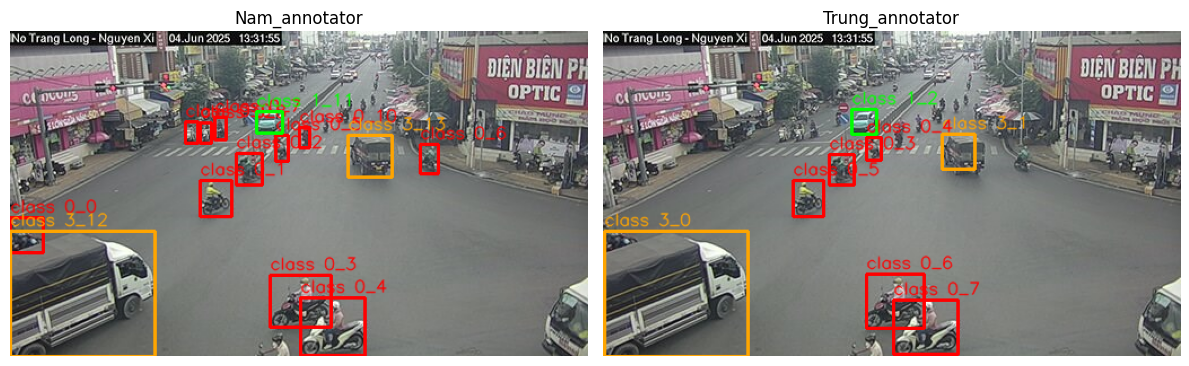

*** Matching Class 0
        box_1   box_2     IoU
   -->  *1*     *5*     0.9643
   -->  *2*     *3*     0.9224
   -->  *3*     *6*     0.9072
   -->  *4*     *7*     0.9412
   -->  *5*     *4*     0.7509

*** Matching Class 1
        box_1   box_2     IoU
   -->  *11*     *2*     0.7644

*** Matching Class 3
        box_1   box_2     IoU
   -->  *12*     *0*     0.9922
   -->  *13*     *1*     0.591

Trung bình IoU của ảnh: 0.8541820219794515

======================= Duong_2_cam_1_3.png =======================


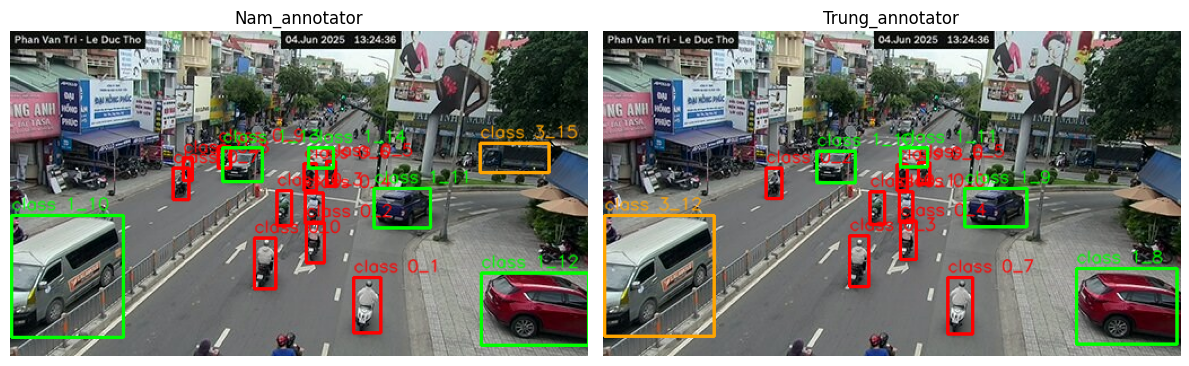

*** Matching Class 0
        box_1   box_2     IoU
   -->  *0*     *3*     0.8223
   -->  *1*     *7*     0.8998
   -->  *2*     *4*     0.7831
   -->  *3*     *1*     0.9355
   -->  *4*     *0*     0.7027
   -->  *5*     *5*     0.7103
   -->  *6*     *6*     0.7841
   -->  *7*     *2*     0.9643

*** Matching Class 1
        box_1   box_2     IoU
   -->  *11*     *9*     0.8854
   -->  *12*     *8*     0.8712
   -->  *13*     *10*     0.8469
   -->  *14*     *11*     0.8698

*** Matching Class 3
        box_1   box_2     IoU

Trung bình IoU của ảnh: 0.8396033795266235

======================= Duong_2_cam_1_50.png =======================


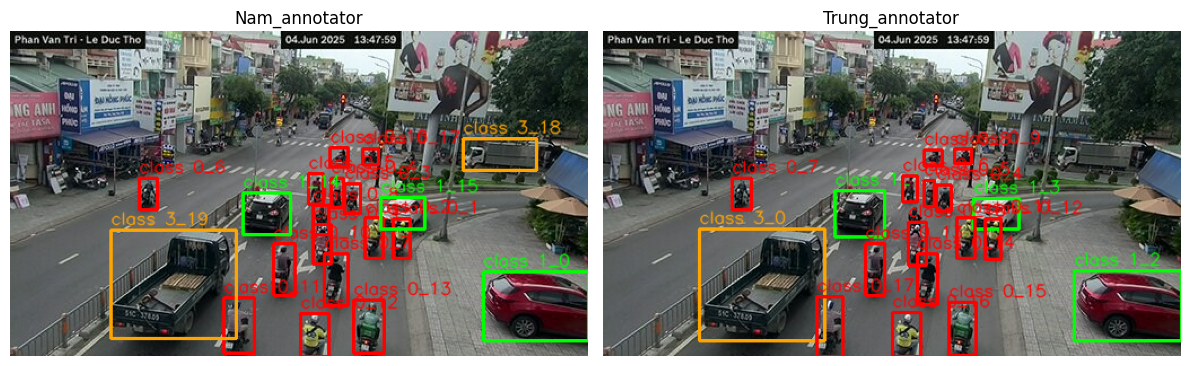

*** Matching Class 0
        box_1   box_2     IoU
   -->  *1*     *12*     0.7927
   -->  *2*     *11*     0.8824
   -->  *3*     *4*     0.7132
   -->  *4*     *5*     0.7238
   -->  *5*     *6*     0.738
   -->  *6*     *7*     0.9412
   -->  *7*     *14*     0.8385
   -->  *9*     *10*     0.7227
   -->  *10*     *13*     0.8
   -->  *11*     *17*     0.7965
   -->  *12*     *16*     0.9003
   -->  *13*     *15*     0.82
   -->  *16*     *8*     0.7343
   -->  *17*     *9*     0.8708

*** Matching Class 1
        box_1   box_2     IoU
   -->  *0*     *2*     0.9632
   -->  *14*     *1*     0.8614
   -->  *15*     *3*     0.941

*** Matching Class 3
        box_1   box_2     IoU
   -->  *19*     *0*     0.9032

Trung bình IoU của ảnh: 0.8301684846275619

======================= Duong_2_cam_2_14.png =======================


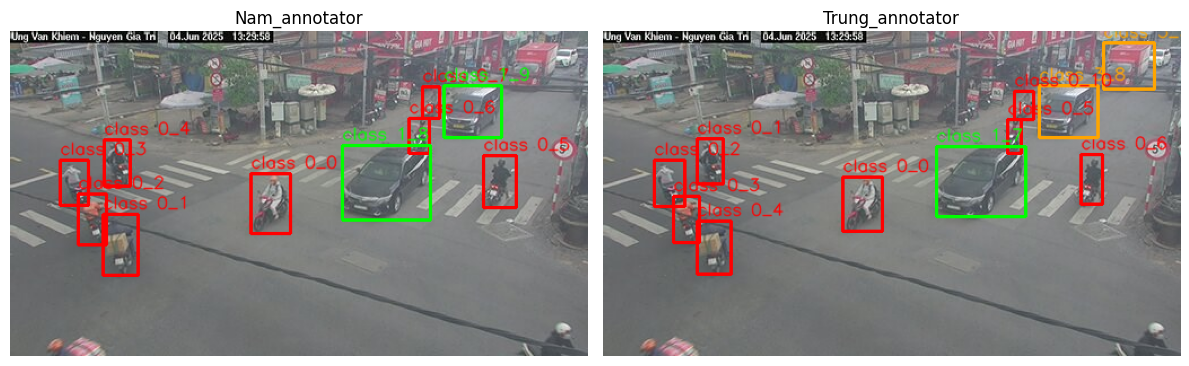

*** Matching Class 0
        box_1   box_2     IoU
   -->  *0*     *0*     0.8576
   -->  *1*     *4*     0.8423
   -->  *2*     *3*     0.8382
   -->  *3*     *2*     0.837
   -->  *4*     *1*     0.9286
   -->  *5*     *6*     0.6038
   -->  *6*     *5*     0.6452
   -->  *7*     *10*     0.7423

*** Matching Class 1
        box_1   box_2     IoU
   -->  *8*     *7*     0.9055

*** Matching Class 3
        box_1   box_2     IoU

Trung bình IoU của ảnh: 0.8000509074834159

======================= Duong_3_cam_1_33.png =======================


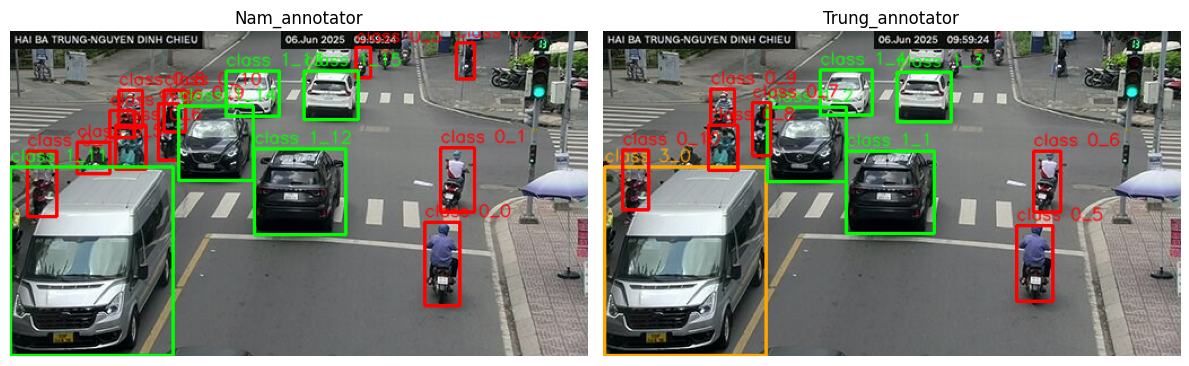

*** Matching Class 0
        box_1   box_2     IoU
   -->  *0*     *5*     0.8797
   -->  *1*     *6*     0.7579
   -->  *4*     *10*     0.7812
   -->  *6*     *8*     0.9398
   -->  *8*     *9*     0.8322
   -->  *9*     *7*     0.8035

*** Matching Class 1
        box_1   box_2     IoU
   -->  *12*     *1*     0.9024
   -->  *13*     *4*     0.9315
   -->  *14*     *2*     0.9155
   -->  *15*     *3*     0.9333

*** Matching Class 3
        box_1   box_2     IoU

Trung bình IoU của ảnh: 0.8676945242607956

======================= Duong_3_cam_1_7.png =======================


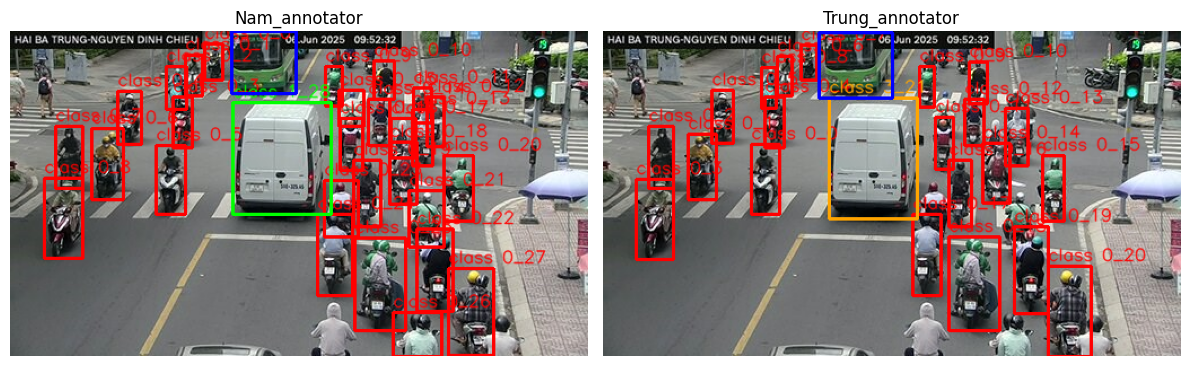

*** Matching Class 0
        box_1   box_2     IoU
   -->  *0*     *7*     0.7422
   -->  *1*     *6*     0.7304
   -->  *2*     *8*     0.6842
   -->  *3*     *4*     0.8889
   -->  *4*     *5*     0.8688
   -->  *5*     *0*     0.8756
   -->  *6*     *1*     0.822
   -->  *7*     *2*     0.9167
   -->  *8*     *3*     0.8899
   -->  *9*     *9*     0.8457
   -->  *10*     *10*     0.7811
   -->  *13*     *13*     0.8824
   -->  *14*     *12*     0.8
   -->  *16*     *11*     0.7692
   -->  *18*     *14*     0.9636
   -->  *19*     *16*     0.8333
   -->  *20*     *15*     0.7308
   -->  *22*     *19*     0.7855
   -->  *24*     *17*     0.8065
   -->  *25*     *18*     0.9452
   -->  *27*     *20*     0.7476

*** Matching Class 1
        box_1   box_2     IoU

*** Matching Class 2
        box_1   box_2     IoU
   -->  *29*     *22*     0.8043

*** Matching Class 3
        box_1   box_2     IoU

Trung bình IoU của ảnh: 0.8233600042169255

======================= Duong_3_cam_2_10.png =

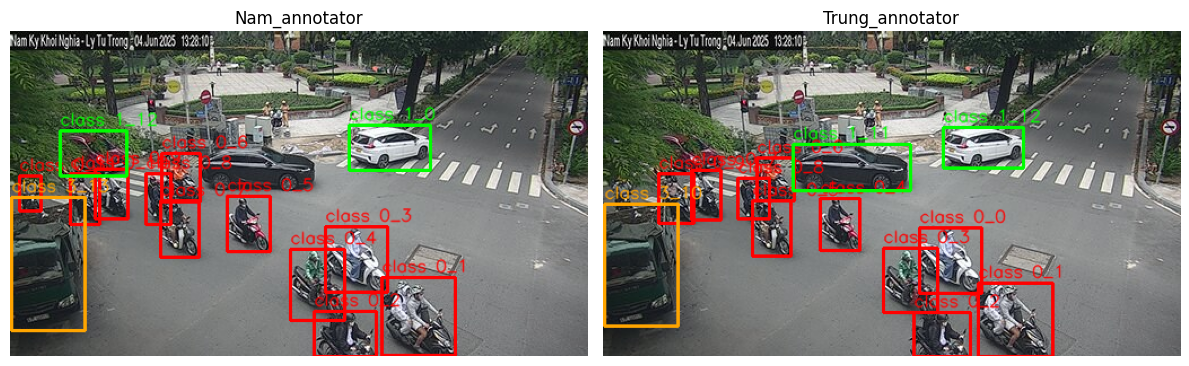

*** Matching Class 0
        box_1   box_2     IoU
   -->  *1*     *1*     0.8255
   -->  *2*     *2*     0.8535
   -->  *3*     *0*     0.9322
   -->  *4*     *3*     0.875
   -->  *5*     *4*     0.8647
   -->  *6*     *6*     0.8107
   -->  *7*     *5*     0.9245
   -->  *8*     *8*     0.6567
   -->  *9*     *7*     0.8587
   -->  *10*     *9*     0.823

*** Matching Class 1
        box_1   box_2     IoU
   -->  *0*     *12*     0.8875

*** Matching Class 3
        box_1   box_2     IoU
   -->  *13*     *10*     0.9153

Trung bình IoU của ảnh: 0.8522632531723081

======================= Duong_3_cam_2_29.png =======================


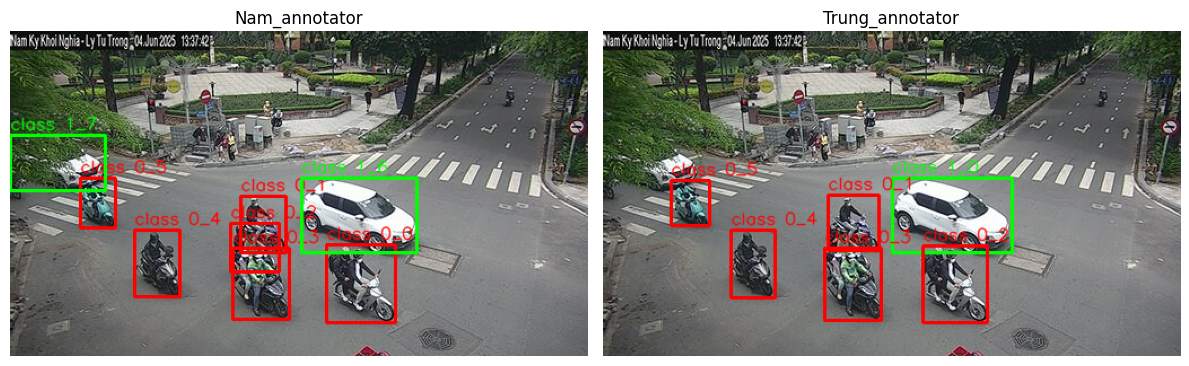

*** Matching Class 0
        box_1   box_2     IoU
   -->  *0*     *2*     0.9209
   -->  *1*     *1*     0.8403
   -->  *3*     *3*     0.9461
   -->  *4*     *4*     0.8673
   -->  *5*     *5*     0.8356

*** Matching Class 1
        box_1   box_2     IoU
   -->  *6*     *0*     0.9623

Trung bình IoU của ảnh: 0.8953923864152724

======================= Duong_4_cam_1_33.png =======================


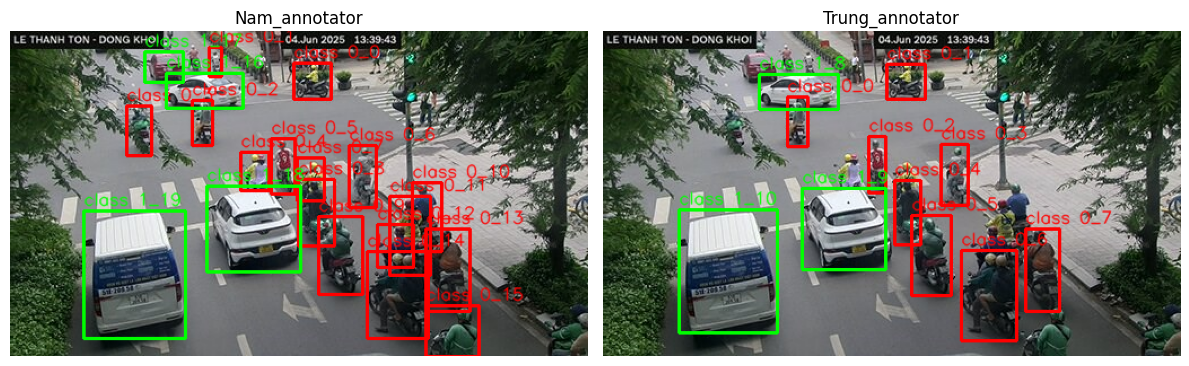

*** Matching Class 0
        box_1   box_2     IoU
   -->  *0*     *1*     0.9411
   -->  *2*     *0*     0.7339
   -->  *5*     *2*     0.6799
   -->  *6*     *3*     0.8726
   -->  *8*     *4*     0.6944
   -->  *9*     *5*     0.8747
   -->  *13*     *7*     0.7692
   -->  *14*     *6*     0.8764

*** Matching Class 1
        box_1   box_2     IoU
   -->  *16*     *8*     0.9115
   -->  *18*     *9*     0.8446
   -->  *19*     *10*     0.9161

Trung bình IoU của ảnh: 0.8285897743400106

======================= Duong_4_cam_2_20.png =======================


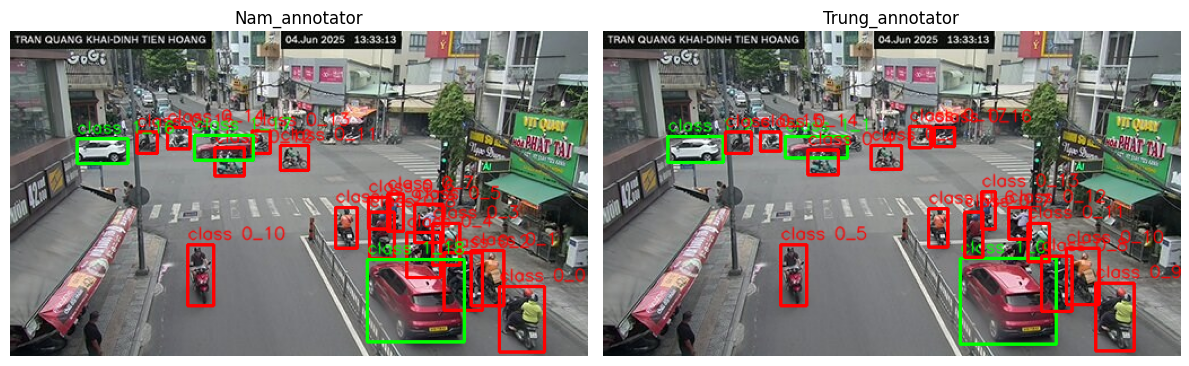

*** Matching Class 0
        box_1   box_2     IoU
   -->  *0*     *9*     0.8002
   -->  *1*     *10*     0.8229
   -->  *2*     *8*     0.7359
   -->  *3*     *11*     0.7275
   -->  *5*     *12*     0.6259
   -->  *7*     *13*     0.7654
   -->  *8*     *7*     0.7095
   -->  *9*     *6*     0.845
   -->  *10*     *5*     1.0
   -->  *11*     *3*     0.8868
   -->  *12*     *4*     0.8512
   -->  *14*     *14*     0.649
   -->  *15*     *15*     0.7826

*** Matching Class 1
        box_1   box_2     IoU
   -->  *16*     *2*     0.8063
   -->  *17*     *1*     0.8226
   -->  *18*     *0*     0.9498

Trung bình IoU của ảnh: 0.7987962762095622



In [23]:
result = []
for index, filename in enumerate(os.listdir(os.path.join(source, "img"))):
    
    print(f"======================= {filename} =======================")
    boxes_1, boxes_2 = finish_img(img_dir[index], nam_label_dir[index], trung_label_dir[index], CLASS_COLORS)
    IoU_each_img = match_boxes(boxes_1, boxes_2)
    result.append(IoU_each_img)
    print()

In [11]:
result

[np.float64(0.8191747594699702),
 np.float64(0.8541820219794515),
 np.float64(0.8396033795266235),
 np.float64(0.8301684846275619),
 np.float64(0.8000509074834159),
 np.float64(0.8676945242607956),
 np.float64(0.8233600042169255),
 np.float64(0.8522632531723081),
 np.float64(0.8953923864152724),
 np.float64(0.8285897743400106),
 np.float64(0.7987962762095622)]

In [12]:
# Độ đồng thuận
print(f"Độ đồng thuận IoU: {round(sum(result) / len(result), 3)}")

Độ đồng thuận IoU: 0.837
